# Personal Information
Name: **Brent Brakenhoff**

StudentID: **13068989**

Email: [**brakenhoff.brent@gmail.com**](brakenhoff.brent@gmail.com)

Github: [**https://github.com/Brebber/Thesis**](https://github.com/Brebber/Thesis)

Submitted on: **23.03.2025**

# Data Context
The dataset consists of two datasets from rijdendetreinen.nl, the services dataset from 2019-2024 and the disruption datasets from these same years. These datasets have been appended and transformed so we have a daily overview over wether a trajectory has been disrupted that day. Additionally, the daily weather data has been sourced from KNMI, for a few different weather stations. This has been merged with the daily trajectory dataset based on the closest weather station to the source of the trajectory. For the train stations coordinates, the stations-2019-nl dataset has been used, also provided by rijdendetreinen.nl.

The main dataset has already been proprocessed, all the trajectories have been grouped by day, the daily weather data has been added. Apart from the data, origin and destination of each trajectory, the dataset contains the number of rides planned, the total final arrival delay of that day, the amount of times a final arrival heas been cancelled, the amount of times the trajectory has been completely cancelled and the total amount of intermediate arrival delays. From the disruptions dataset, a list of the statistical causes of the disruptions that occured that day has been added, as well as the total amount of disruptions that day and a binary variable that is true if the trajectory has been disrupted at least once that day. The added weather variables are:

FHVEC     : Vector mean windspeed (in 0.1 m/s)<br>
TG        : Daily mean temperature in (0.1 degrees Celsius<br>
TN        : Minimum temperature (in 0.1 degrees Celsius)<br>
TX        : Maximum temperature (in 0.1 degrees Celsius)<br>
T10N      : Minimum temperature at 10 cm above surface (in 0.1 degrees Celsius)<br>
SQ        : Sunshine duration (in 0.1 hour) calculated from global radiation (-1 for <0.05 hour)<br>
DR        :Precipitation duration (in 0.1 hour)<br>
RH        : Daily precipitation amount (in 0.1 mm) (-1 for <0.05 mm)<br>
RHX       : Maximum hourly precipitation amount (in 0.1 mm) (-1 for <0.05 mm)<br>
VVX       : Maximum visibility <br>


# Data Description

In [45]:
# Imports
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

### Data Loading

In [ ]:
# Load main dataset
disruptions_df = pd.read_csv('daily_disruptions_weather.csv')
disruptions_df['Date'] = pd.to_datetime(disruptions_df['Date'])

# Load data necessary for graph
coordinates_df = pd.read_csv('stations-2023-09-nl.csv')
distances_df = pd.read_csv('station_distances.csv')

# Merge distance data
disruptions_df = disruptions_df.merge(
    distances_df, 
    how='left', 
    left_on=['source', 'target'], 
    right_on=['origin_name', 'destination_name']
)
disruptions_df['distance'] = disruptions_df['distance'].fillna(0)
disruptions_df = disruptions_df.drop(columns=['Unnamed: 0','origin_name', 'destination_name'])
disruptions_df


C:\Users\brake\AppData\Local\Temp\ipykernel_7304\1813439240.py:2: DtypeWarning:

Columns (10,11,12,13,14,15,16,18,19) have mixed types. Specify dtype option on import or set low_memory=False.



,Date,source,target,Rides planned,Final arrival delay,Final arrival cancelled,Completely cancelled,Intermediate arrival delays,Statistical Causes,Disruption Count,...,SQ,TG,TN,TX,RHX,VVX,T10N,FHVEC,Disrupted,distance
0,2019-01-01,'s-Hertogenbosch,Arnhem Centraal,1,0,0,0,1,No Disruption,0.0,...,7,70,42,87,4,74,28,40,False,62.0
1,2019-01-01,'s-Hertogenbosch,Den Haag Centraal,33,4,2,0,27,No Disruption,0.0,...,7,70,42,87,4,74,28,40,False,108.0
2,2019-01-01,'s-Hertogenbosch,Deurne,17,4,1,0,11,No Disruption,0.0,...,7,70,42,87,4,74,28,40,False,54.0
3,2019-01-01,'s-Hertogenbosch,Dordrecht,11,0,0,0,3,No Disruption,0.0,...,7,70,42,87,4,74,28,40,False,73.0
4,2019-01-01,'s-Hertogenbosch,Eindhoven Centraal,18,2,0,0,7,No Disruption,0.0,...,7,70,42,87,4,74,28,40,False,32.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
654431,2024-12-31,Zwolle,Nijmegen,1,0,0,0,1,No Disruption,0.0,...,0.0,52.0,29.0,79.0,-1.0,80,29.0,82.0,False,95.0
654432,2024-12-31,Zwolle,Roosendaal,31,5,6,0,28,No Disruption,0.0,...,0.0,52.0,29.0,79.0,-1.0,80,29.0,82.0,False,201.0
654433,2024-12-31,Zwolle,Schiphol Airport,1,0,0,0,0,No Disruption,0.0,...,0.0,52.0,29.0,79.0,-1.0,80,29.0,82.0,False,121.0
654434,2024-12-31,Zwolle,Utrecht Centraal,29,1,0,0,19,No Disruption,0.0,...,0.0,52.0,29.0,79.0,-1.0,80,29.0,82.0,False,87.0


### Data Imbalance

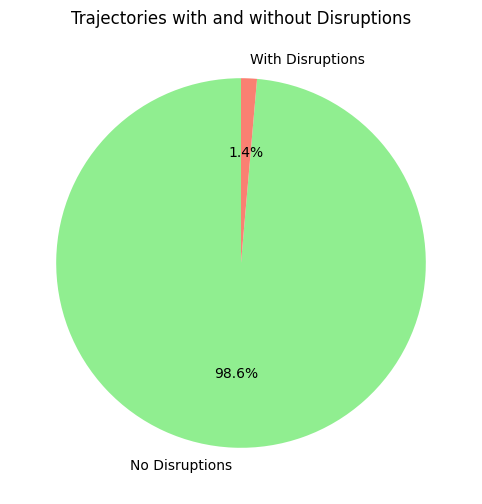

In [19]:
import matplotlib.pyplot as plt

# Count the number of trajectories with Disruption Count == 0 and > 0
disrupted = (disruptions_df["Disrupted"] == True).sum()
non_disrupted =  (disruptions_df["Disrupted"] == False).sum()

# Data for the pie chart
labels = ['No Disruptions', 'With Disruptions']
sizes = [non_disrupted, disrupted]
colors = ['lightgreen', 'salmon']

# Plot the pie chart
plt.figure(figsize=(8, 6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors)
plt.title('Trajectories with and without Disruptions')
plt.show()

## Most Common Statistical Causes Over Time

C:\Users\brake\AppData\Local\Temp\ipykernel_7304\2703092600.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



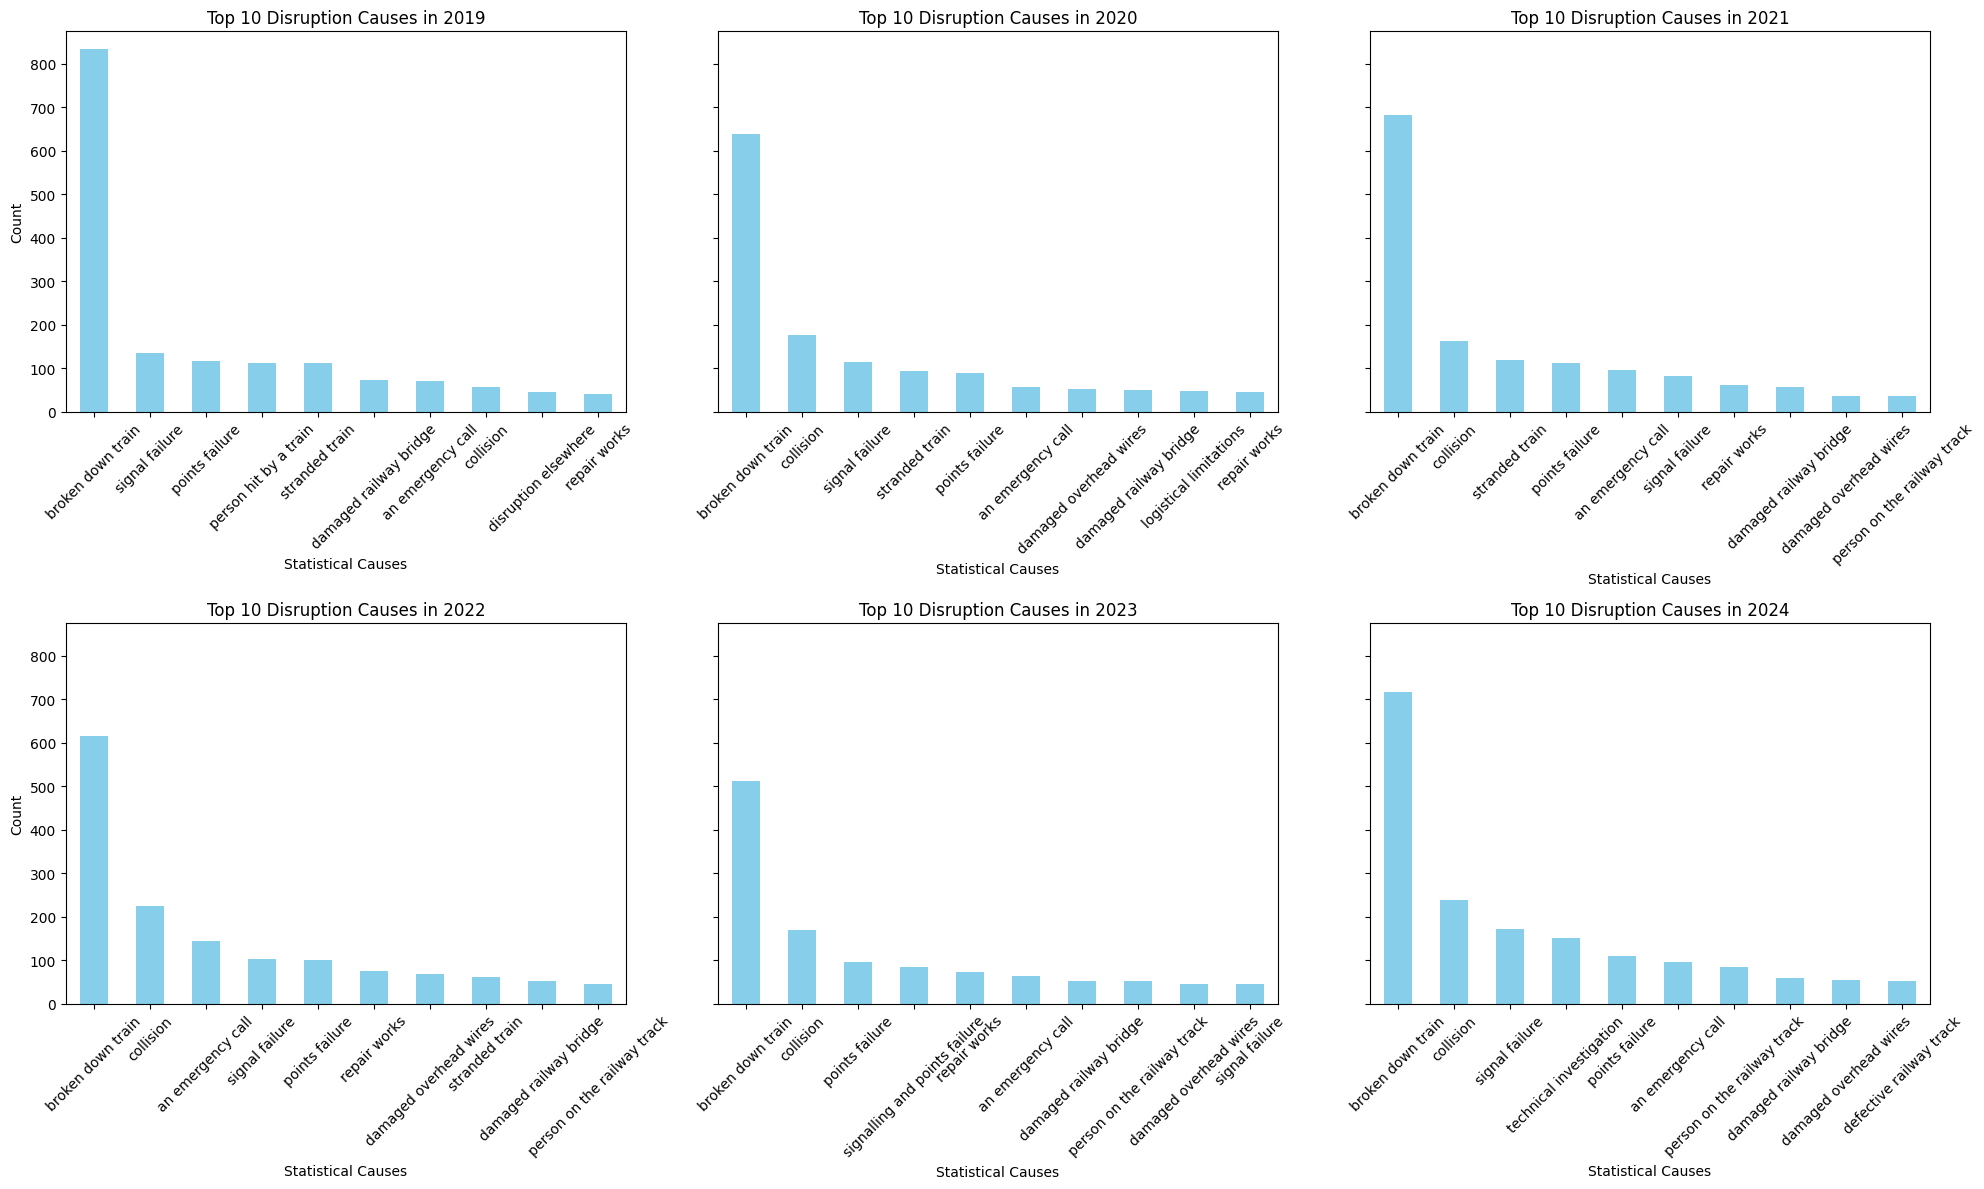

In [20]:
disrupted_df = disruptions_df[disruptions_df['Disrupted'] == True]
disrupted_df['Year'] = pd.to_datetime(disrupted_df['Date']).dt.year

# Explode the 'Statistical Causes' column to separate individual causes
disrupted_df_exploded = disrupted_df.copy()
disrupted_df_exploded['Statistical Causes'] = disrupted_df_exploded['Statistical Causes'].apply(eval)  # Convert string representation of list to actual list
disrupted_df_exploded = disrupted_df_exploded.explode('Statistical Causes')

# Group by year and cause, then count occurrences
causes_by_year = disrupted_df_exploded.groupby(['Year', 'Statistical Causes']).size().unstack(fill_value=0)

# Create subplots for all years in the same figure
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(20, 12), sharey=True)

# Flatten the axes array for easier iteration
axes = axes.flatten()

# Plot each year's data in a separate subplot
for i, year in enumerate(causes_by_year.index):
    ax = axes[i]
    causes_by_year.loc[year].nlargest(10).sort_values(ascending=False).plot(kind='bar', color='skyblue', ax=ax)
    ax.set_title(f'Top 10 Disruption Causes in {year}')
    ax.set_xlabel('Statistical Causes')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=45)

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

## Outliers

In [21]:
top_10_disruptions = disruptions_df.sort_values(by='Disruption Count', ascending=False)[['Date','source', 'target', 'Disruption Count']].head(10)
top_10_disruptions

,Date,source,target,Disruption Count
97240,2019-12-02,Amsterdam Centraal,Schiphol Airport,9.0
489037,2023-07-05,Alkmaar,Amsterdam Centraal,7.0
117997,2020-02-08,Amsterdam Centraal,Utrecht Centraal,7.0
376979,2022-06-27,Amsterdam Centraal,Schiphol Airport,6.0
370671,2022-06-07,'s-Hertogenbosch,Utrecht Centraal,6.0
96362,2019-11-29,Amsterdam Centraal,Utrecht Centraal,6.0
1932,2019-01-08,Almelo,Deventer,5.0
121446,2020-02-19,Amsterdam Centraal,Schiphol Airport,5.0
489737,2023-07-07,Amsterdam Centraal,Haarlem,5.0
80299,2019-10-08,Amsterdam Centraal,Schiphol Airport,5.0


In [22]:
summed_disruptions = disruptions_df.groupby(['source', 'target'])[[ 'Rides planned', 'Disruption Count']].sum().reset_index()
summed_disruptions = summed_disruptions.sort_values(by='Disruption Count', ascending=False)

# Display the top 10 most disrupted trajectories
summed_disruptions.head(10)

,source,target,Rides planned,Disruption Count
680,Amsterdam Centraal,Utrecht Centraal,10012,847.0
59,'s-Hertogenbosch,Utrecht Centraal,34155,784.0
1656,Den Haag Centraal,Utrecht Centraal,36528,758.0
131,Alkmaar,Amsterdam Centraal,16234,705.0
1337,Breda,Dordrecht,7402,653.0
2523,Groningen,Zwolle,67157,542.0
1025,Arnhem Centraal,Nijmegen,20816,495.0
613,Amsterdam Centraal,Haarlem,8850,481.0
3908,Roosendaal,Vlissingen,18700,454.0
1979,Dordrecht,Rotterdam Centraal,10610,445.0


In [23]:
# Display the 10 least disrupted trajectories
summed_disruptions = summed_disruptions.sort_values(by='Disruption Count', ascending=True)
summed_disruptions.head(10)

,source,target,Rides planned,Disruption Count
4403,Tilburg,Den Haag Centraal,827,0.0
18,'s-Hertogenbosch,Deventer,117,0.0
39,'s-Hertogenbosch,Leiden Centraal,11865,0.0
84,'t Harde,Ermelo,2,0.0
40,'s-Hertogenbosch,Maastricht,984,0.0
43,'s-Hertogenbosch,Nijmegen Goffert,3,0.0
67,'s-Hertogenbosch,Vught,32,0.0
68,'s-Hertogenbosch,Weert,5,0.0
17,'s-Hertogenbosch,Deurne,55874,0.0
69,'s-Hertogenbosch,Wijchen,1354,0.0


### Pearson's Correlation Between Variables

In [24]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import seaborn as sns

# Strip column names to remove leading/trailing spaces
disruptions_df.columns = disruptions_df.columns.str.strip()

# Select weather-related features
weather_features = ['RH', 'SQ', 'TG', 'TN', 'TX', 'RHX', 'VVX', 'T10N', 'FHVEC']
weather_data = disruptions_df[weather_features].dropna()

# Clean the data: strip spaces and coerce non-numeric values to NaN
weather_data = weather_data.applymap(lambda x: str(x).strip() if isinstance(x, str) else x)
weather_data = weather_data.apply(pd.to_numeric, errors='coerce').dropna()
# Standardize the data
scaler = StandardScaler()
weather_data_scaled = scaler.fit_transform(weather_data)

# Add the 'Disrupted' column and other specified columns to the weather data for correlation analysis
columns_to_add = ['Rides planned', 'Final arrival delay', 'Final arrival cancelled', 'Completely cancelled', 'Intermediate arrival delays','distance', 'Disruption Count']
for column in columns_to_add:
    weather_data[column] = disruptions_df.loc[weather_data.index, column].astype(float)

# Compute Pearson's correlation coefficients
correlation_matrix = weather_data.corr(method='pearson')[['Disruption Count']]
print(correlation_matrix)

C:\Users\brake\AppData\Local\Temp\ipykernel_7304\2382102600.py:13: FutureWarning:

DataFrame.applymap has been deprecated. Use DataFrame.map instead.



                             Disruption Count
RH                                   0.001742
SQ                                   0.003050
TG                                   0.006394
TN                                   0.005256
TX                                   0.006743
RHX                                  0.000621
VVX                                  0.001177
T10N                                 0.003777
FHVEC                                0.005219
Rides planned                       -0.015293
Final arrival delay                 -0.010777
Final arrival cancelled              0.000560
Completely cancelled                 0.002781
Intermediate arrival delays         -0.022565
distance                            -0.065018
Disruption Count                     1.000000


### Graph of the overall Network with all  Possible Edges

In [38]:
import plotly.graph_objects as go
import networkx as nx

sources = disruptions_df['source'].unique()
coordinates_df = pd.read_csv('stations-2023-09-nl.csv')
destinations = disruptions_df['target'].unique()
stations = list(set(sources).union(set(destinations)))
edges = disruptions_df[['source', 'target']].values

G = nx.Graph()
G.add_nodes_from(stations)
G.add_edges_from(edges)

# Create a Plotly figure
# Filter coordinates_df to include only stations present in the graph
coordinates_df = coordinates_df[coordinates_df['name_long'].isin(G.nodes())]

# Create a dictionary of positions based on coordinates
pos = {row['name_long']: (row['geo_lng'], row['geo_lat']) for _, row in coordinates_df.iterrows()}

# Remove nodes from the graph that are not in the coordinates_df
nodes_to_remove = [node for node in G.nodes() if node not in pos]
G.remove_nodes_from(nodes_to_remove)

# Extract edge positions
edge_x = []
edge_y = []
for edge in G.edges():
    x0, y0 = pos[edge[0]]
    x1, y1 = pos[edge[1]]
    edge_x.extend([x0, x1, None])
    edge_y.extend([y0, y1, None])

# Create edge trace
edge_trace = go.Scatter(
    x=edge_x, y=edge_y,
    line=dict(width=0.5, color='#888'),
    hoverinfo='none',
    mode='lines'
)

# Extract node positions and attributes
node_x = []
node_y = []
for node in G.nodes():
    x, y = pos[node]
    node_x.append(x)
    node_y.append(y)

# Create node trace
node_trace = go.Scatter(
    x=node_x, y=node_y,
    mode='markers',
    hoverinfo='text',
    marker=dict(
        showscale=True,
        colorscale='YlGnBu',
        size=10,
        colorbar=dict(
            thickness=15,
            title=dict(
                text='Node Connections',
                side='right'
            ),
            xanchor='left'
        )
    )
)

# Add node text
node_adjacencies = []
node_text = []
for node, adjacencies in G.adjacency():
    node_adjacencies.append(len(adjacencies))
    node_text.append(f'{node}<br># of connections: {len(adjacencies)}')

node_trace.marker.color = node_adjacencies
node_trace.text = node_text

# Create the figure
fig = go.Figure(data=[edge_trace, node_trace],
                layout=go.Layout(
                    title='Network Graph',
                    showlegend=False,
                    hovermode='closest',
                    margin=dict(b=0, l=0, r=0, t=0),
                    xaxis=dict(showgrid=False, zeroline=False),
                    yaxis=dict(showgrid=False, zeroline=False)
                ))

fig.show()

![alt text](total_plot.png "Total Graph Plot")

# Creating a Daily Graph with Network Features

In [51]:
# Get unique dates and stations
unique_dates = disruptions_df['Date'].dt.date.unique()
sources = disruptions_df['source'].unique()
destinations = disruptions_df['target'].unique()
stations = list(set(sources).union(set(destinations)))

# Function to create daily graph and calculate node features
def create_daily_graph(date, df):
    # Filter data for the specific date
    daily_df = df[df['Date'].dt.date == date]
    
    # Create graph
    G = nx.Graph()
    G.add_nodes_from(stations)
    
    # Add weighted edges
    for _, row in daily_df.iterrows():
        G.add_edge(
            row['source'], 
            row['target'], 
            weight=row['Rides planned'], 
            distance=row['distance']
        )
    
    # Calculate node features
    node_features = {}
    for node in G.nodes():
        # Degree (number of connections)
        degree = G.degree(node)
        
        # Weighted degree (sum of rides planned)
        weighted_degree = sum(
            G[node][neighbor]['weight'] 
            for neighbor in G.neighbors(node)
        )
        
        # Average distance to neighbors
        avg_distance = (
            sum(G[node][neighbor]['distance'] for neighbor in G.neighbors(node)) / degree
            if degree > 0 else 0
        )
        
        node_features[node] = {
            'degree': degree,
            'weighted_degree': weighted_degree,
            'avg_distance': avg_distance
        }
    
    return G, node_features

# Dictionary to store daily graphs and features
daily_graphs = {}
daily_features = {}

# Process each day
for date in unique_dates:
    G, features = create_daily_graph(date, disruptions_df)
    daily_graphs[date] = G
    daily_features[date] = features

# Example Graph for the First Day of the Dataset

In [ ]:

# Example: Visualize graph for a specific date
def visualize_graph(date, G):  # Position nodes
    
    edge_x = []
    edge_y = []
    for edge in G.edges():
        x0, y0 = pos[edge[0]]
        x1, y1 = pos[edge[1]]
        edge_x.extend([x0, x1, None])
        edge_y.extend([y0, y1, None])
    
    edge_trace = go.Scatter(
        x=edge_x, y=edge_y,
        line=dict(width=0.5, color='#888'),
        hoverinfo='none',
        mode='lines'
    )
    
    node_x = []
    node_y = []
    for node in G.nodes():
        if node not in pos:
            node_x.append(5.5)
            node_y.append(52)
            continue
        x, y = pos[node]
        node_x.append(x)
        node_y.append(y)
    
    node_trace = go.Scatter(
        x=node_x, y=node_y,
        mode='markers',
        hoverinfo='text',
        marker=dict(
            showscale=True,
            colorscale='YlGnBu',
            size=10,
            colorbar=dict(
                thickness=15,
                title=dict(
                    text='Node Connections',
                    side='right'
                ),
                xanchor='left'
            )
        )
    )
    
    # Add node information
    node_text = []
    node_colors = []
    features = daily_features[date]
    for node in G.nodes():
        info = (f"Station: {node}<br>"
                f"Degree: {features[node]['degree']}<br>"
                f"Rides: {features[node]['weighted_degree']}<br>"
                f"Avg Distance: {features[node]['avg_distance']:.2f}")
        node_text.append(info)
        node_colors.append(features[node]['weighted_degree'])
    
    node_trace.text = node_text
    node_trace.marker.color = node_colors
    
    fig = go.Figure(
        data=[edge_trace, node_trace],
        layout=go.Layout(
            title=f'Train Network - {date}',
            showlegend=False,
            hovermode='closest',
            margin=dict(b=20,l=5,r=5,t=40),
        )
    )
    
    fig.show()

# Visualize for a specific date (example)
example_date = unique_dates[0]
visualize_graph(example_date, daily_graphs[example_date])

# # Print features for first date as example
# print(f"Node features for {example_date}:")
# for node, features in daily_features[example_date].items():
#     print(f"{node}: {features}")

Node features for 2019-01-01:
Utrecht Terwijde: {'degree': 0, 'weighted_degree': 0, 'avg_distance': 0}
Ommen: {'degree': 0, 'weighted_degree': 0, 'avg_distance': 0}
Rhenen: {'degree': 3, 'weighted_degree': 34, 'avg_distance': 60.0}
Lage Zwaluwe: {'degree': 0, 'weighted_degree': 0, 'avg_distance': 0}
SSN Stoomdepot: {'degree': 0, 'weighted_degree': 0, 'avg_distance': 0}
Bielefeld Hbf: {'degree': 0, 'weighted_degree': 0, 'avg_distance': 0}
Roosendaal: {'degree': 8, 'weighted_degree': 55, 'avg_distance': 104.5}
Santpoort Zuid: {'degree': 0, 'weighted_degree': 0, 'avg_distance': 0}
Diemen Zuid: {'degree': 0, 'weighted_degree': 0, 'avg_distance': 0}
Driehuis: {'degree': 0, 'weighted_degree': 0, 'avg_distance': 0}
Amersfoort Centraal: {'degree': 6, 'weighted_degree': 35, 'avg_distance': 91.5}
Lansingerland-Zoetermeer: {'degree': 0, 'weighted_degree': 0, 'avg_distance': 0}
Rotterdam Stadion: {'degree': 0, 'weighted_degree': 0, 'avg_distance': 0}
Rotterdam Beurs: {'degree': 0, 'weighted_degree

![alt text](daily_plot.png "Daily Graph Plot")

# Simple Logistic Regression for the First Month of the Dataset
Due to the imbalanced nature of the dataset, the model only seems to predict that a trajectory is not disrupted. This is a problem that will need to be resolved in the final model.

Classification Report:
              precision    recall  f1-score   support

       False       0.99      1.00      0.99      1724
        True       0.00      0.00      0.00        24

    accuracy                           0.99      1748
   macro avg       0.49      0.50      0.50      1748
weighted avg       0.97      0.99      0.98      1748


Confusion Matrix:


c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

c:\Users\brake\UVA_AML24\week_1\.conda\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.



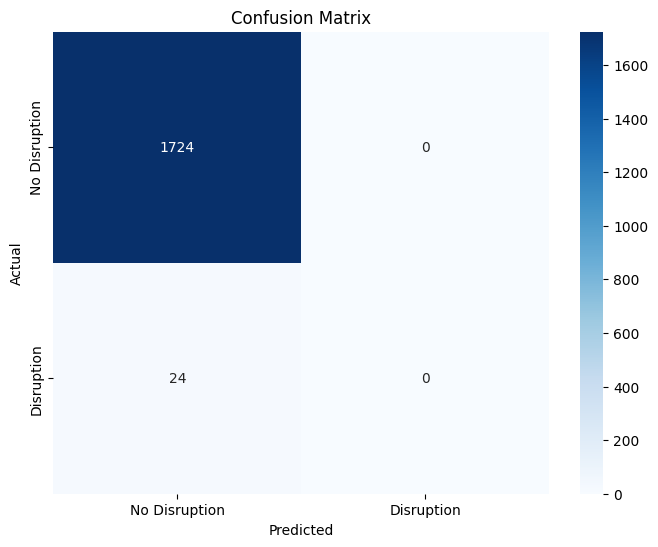

Feature Coefficients:
source_degree: -0.5219
source_weighted_degree: 0.7859
source_avg_distance: 0.7625
target_degree: 1.5596
target_weighted_degree: -1.2392
target_avg_distance: 0.4873
distance: -2.0096
rides_planned: -0.0377


In [50]:
# Assuming disruptions_df and daily_features are available from previous code
# Filter first month (assuming dates are in 2025)
start_date = pd.to_datetime('2019-01-01')
end_date = pd.to_datetime('2019-01-31')
first_month_df = disruptions_df[
    (disruptions_df['Date'] >= start_date) & 
    (disruptions_df['Date'] <= end_date)
]
first_month_dates = first_month_df['Date'].dt.date.unique()

# Prepare feature dataset
feature_data = []
target = []

for date in first_month_dates:
    daily_df = first_month_df[first_month_df['Date'].dt.date == date]
    features = daily_features[date]
    
    # For each source-target pair in the daily data
    for _, row in daily_df.iterrows():
        source = row['source']
        destination = row['target']
        disrupted = row['Disrupted']  # Assuming this column exists
        
        # Combine features from source and target nodes
        combined_features = [
            features[source]['degree'],
            features[source]['weighted_degree'],
            features[source]['avg_distance'],
            features[destination]['degree'],
            features[destination]['weighted_degree'],
            features[destination]['avg_distance'],
            row['distance'],  # Add edge distance as a feature
            row['Rides planned']  # Add rides planned as a feature
        ]
        
        feature_data.append(combined_features)
        target.append(disrupted)

# Convert to numpy arrays
X = np.array(feature_data)
y = np.array(target)

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train logistic regression classifier
classifier = LogisticRegression(random_state=42)
classifier.fit(X_train_scaled, y_train)

# Evaluate the model
y_pred = classifier.predict(X_test_scaled)
print("Classification Report:")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:")
# Plot the confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Disruption', 'Disruption'], yticklabels=['No Disruption', 'Disruption'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Feature importance (coefficients)
feature_names = [
    'source_degree', 'source_weighted_degree', 'source_avg_distance',
    'target_degree', 'target_weighted_degree', 'target_avg_distance',
    'distance', 'rides_planned'
]
print("Feature Coefficients:")
for name, coef in zip(feature_names, classifier.coef_[0]):
    print(f"{name}: {coef:.4f}")